In [23]:
from sklearn.metrics import roc_auc_score, average_precision_score
import torch

checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/CBI/test_splits=1_4_7_10_11_train_splits=2_3_5_6_8_val_splits=9/OnTheDesign_wd_1e-06_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/CBI/test_splits=2_6_train_splits=3_5_8_9_val_splits=1_4_7_10_11/OnTheDesign_wd_0.0_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/CBI/test_splits=3_8_train_splits=1_4_5_7_9_10_11_val_splits=2_6/OnTheDesign_wd_0.0_lr_0.0001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/CBI/test_splits=5_train_splits=1_2_4_6_7_9_10_11_val_splits=3_8/OnTheDesign_wd_0.001_lr_0.01_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/CBI/test_splits=9_train_splits=1_2_3_4_6_7_8_10_11_val_splits=5/OnTheDesign_wd_0.01_lr_0.0001_rs_1001.pt", map_location=torch.device("cpu"))

checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/WMD/test_splits=1_4_7_10_11_train_splits=2_3_5_6_8_val_splits=9/OnTheDesign_wd_1e-06_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/WMD/test_splits=2_6_train_splits=3_5_8_9_val_splits=1_4_7_10_11/OnTheDesign_wd_1e-05_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/WMD/test_splits=3_8_train_splits=1_4_5_7_9_10_11_val_splits=2_6/OnTheDesign_wd_1e-05_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/WMD/test_splits=5_train_splits=1_2_4_6_7_9_10_11_val_splits=3_8/OnTheDesign_wd_0.01_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))
checkpoint = torch.load("/cluster/tufts/hugheslab/dloevl01/brain-scan-classifiers/experiments/KPSC_MRI/OnTheDesign/saved/WMD/test_splits=9_train_splits=1_2_3_4_6_7_8_10_11_val_splits=5/OnTheDesign_wd_1e-06_lr_0.001_rs_1001.pt", map_location=torch.device("cpu"))

print(roc_auc_score(torch.stack(checkpoint["test_labels"]).numpy(), torch.stack(checkpoint["test_logits"]).numpy()))
print(average_precision_score(torch.stack(checkpoint["test_labels"]).numpy(), torch.stack(checkpoint["test_logits"]).numpy()))


0.7217194570135747
0.8687584666977493


In [29]:
import numpy as np

aurocs = [0.6615305598356446, 0.7163120567375886, 0.6990950226244343, 0.6783779600681009, 0.6336567413850787]
auprcs = [0.41012757393753296, 0.5435767401666827, 0.5097962718359165, 0.6233135956926878, 0.3952431343001643]

print(f"{np.mean(aurocs):.3f} \pm {np.std(aurocs):.3f}")
print(f"{np.mean(auprcs):.3f} \pm {np.std(auprcs):.3f}")

aurocs = [0.6576867816091954, 0.6730025773195876, 0.7011936850211783, 0.7767676767676768, 0.7217194570135747]
auprcs = [0.7170619488087511, 0.7508078263265259, 0.8489320208824438, 0.9453948706904671, 0.8687584666977493]

print(f"{np.mean(aurocs):.3f} \pm {np.std(aurocs):.3f}")
print(f"{np.mean(auprcs):.3f} \pm {np.std(auprcs):.3f}")


0.678 \pm 0.029
0.496 \pm 0.085
0.706 \pm 0.042
0.826 \pm 0.083


In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
import ants
import torch
import torchvision


In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import ct
import utils


In [5]:
nifti_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT'
labels_df = ct.label_oasis3(nifti_dir)
print(labels_df.shape)
print(len(labels_df[["Subject"]].value_counts()))
labels_df.head()


(658, 40)
493


,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,acsparnt,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths
7,OAS30001_CT_d2438,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,64.0,184.0,NaN,NaN,2699,-261,261,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
21,OAS30001_CT_d3132,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
34,OAS30001_CT_d3746,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
54,OAS30002_CT_d2345,OAS30002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2585,-240,240,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...
59,OAS30003_CT_d2669,OAS30003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2630,39,39,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...


(512, 512, 74)


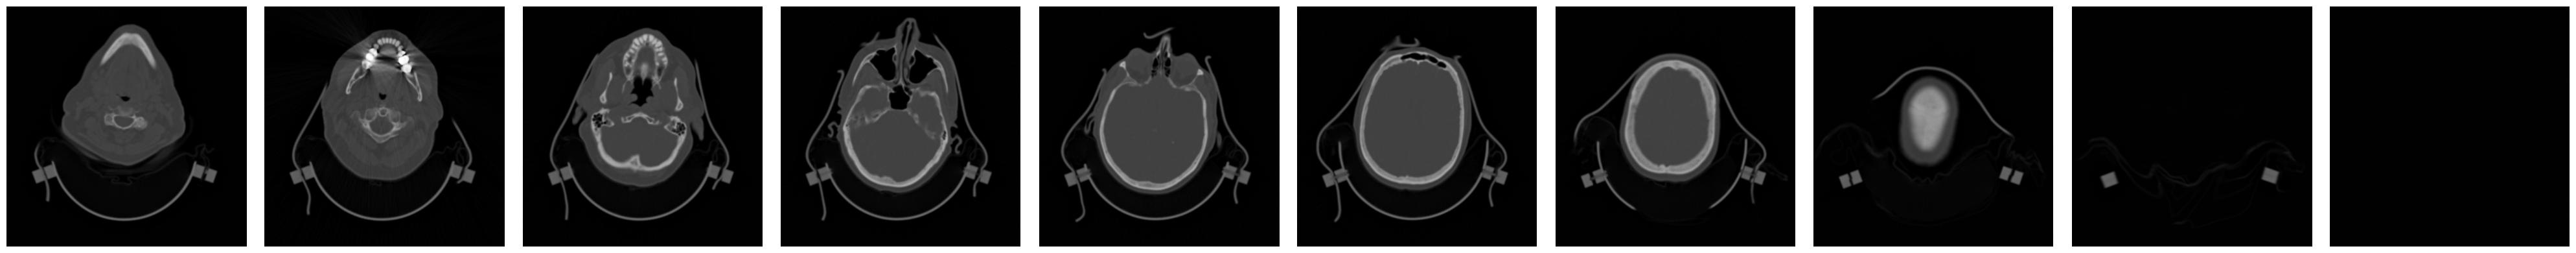

In [7]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()


In [8]:
numpy_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy'
starts = np.linspace(0, 1620, num=11).astype(int)[:-1]
stops = np.linspace(0, 1620, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f'    \"python ../src/preprocess_oasis-3_ct.py --nifti_dir=\'{nifti_dir}\' --numpy_dir=\'{numpy_dir}\' --start={start} --stop={stop}\"')
    

    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=0 --stop=162"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=162 --stop=324"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=324 --stop=486"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=486 --stop=648"
    "python ../src/preprocess_oasis-3_ct.py --nifti_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT' --numpy_dir='/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy' --start=648 --stop=810"
    "python ../src/preprocess_oasis-3_ct.p

In [9]:
labels_df['path'] = labels_df["XNAT_CTSESSIONDATA ID"].apply(lambda ct_id: f"{numpy_dir}/{ct_id}.npz")
#labels_df.to_csv(f'{numpy_dir}/labels.csv', index=False)
labels_df.head()


,XNAT_CTSESSIONDATA ID,Subject,Date_x,Age_x,dcmAccessionNumber,dcmPatientId,dcmPatientName,UID,FreeSurfers,PUPs,...,height,weight,primStudy,acsStudy,diagnosis_day,diff,abs_diff,Alzheimer's,paths,path
7,OAS30001_CT_d2438,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.0,184.0,NaN,NaN,2699,-261,261,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
21,OAS30001_CT_d3132,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,63.0,185.0,NaN,NaN,3332,-200,200,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
34,OAS30001_CT_d3746,OAS30001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,64.0,192.0,NaN,NaN,3675,71,71,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
54,OAS30002_CT_d2345,OAS30002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2585,-240,240,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...
59,OAS30003_CT_d2669,OAS30003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2630,39,39,0,[/cluster/tufts/hugheslab/datasets/OASIS-3_CT/...,/cluster/tufts/hugheslab/datasets/OASIS-3_CT_n...


In [12]:
np.round(np.linspace(0, 73, num=5)).astype(int)[1:-1]

array([18, 36, 55])

(1, 512, 512, 74)


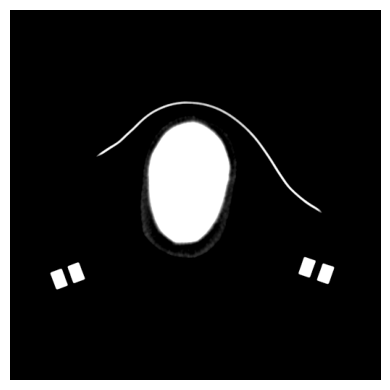

In [16]:
image = np.load(labels_df.iloc[0].path)["arr_0"]
print(image.shape)

fig, ax = plt.subplots(figsize=(4*ncols,4*nrows), ncols=1, nrows=1)

ax.imshow(np.rot90(image[0,:,:,55], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image[0]), vmax=np.max(image[0]))
ax.set_axis_off()
    
fig.tight_layout()
fig.savefig("example_ct_55.pdf", bbox_inches="tight")
plt.show()

In [5]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = '--embedding_level ' if embedding_level else ''
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/oasis-3.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'{embedding_level}'
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model_name=\'{model_name}\' '
        f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
    
################################################################################
#"""
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, experiments_dir, lr, 
    model, num_channels, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/fine-tune_oasis-3.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model=\'{model}\' '
        f'--model_name=\'{model_name}\' '
        f'--num_channels={num_channels} '
        #f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
#"""

In [16]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
#alphas = [0.0]
batch_size = 4
criterions = ['L2']
#dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_CT_numpy'
#dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy'
dataset_dir = '/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy'
epochs = 100
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_OnTheDesign' 
lrs = [0.1, 0.01, 0.001, 0.0001]
model = "3D ResNet-18"
#model = "ViT-B/16"
num_channels = 1
pooling = "Mean"
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, seed in itertools.product(alphas, criterions, lrs, seeds):

    print_job(alpha, batch_size, criterion, dataset_dir, epochs, 
              experiments_dir, lr, model, num_channels, pooling, save, 
              seed, weight_decay)
    

    "python ../src/fine-tune_oasis-3.py --alpha=1.0 --batch_size=4 --criterion='L2' --dataset_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --epochs=100 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18' --lr=0.1 --model='3D ResNet-18' --model_name='alpha=1.0_criterion=L2_lr=0.1_seed=1001' --num_channels=1 --save --seed=1001 --weight_decay=0.0"
    "python ../src/fine-tune_oasis-3.py --alpha=1.0 --batch_size=4 --criterion='L2' --dataset_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --epochs=100 --experiments_dir='/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_3D_ResNet-18' --lr=0.1 --model='3D ResNet-18' --model_name='alpha=1.0_criterion=L2_lr=0.1_seed=2001' --num_channels=1 --save --seed=2001 --weight_decay=0.0"
    "python ../src/fine-tune_oasis-3.py --alpha=1.0 --batch_size=4 --criterion='L2' --dataset_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --epochs=1

In [7]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=False'
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)
    

In [11]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=False' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=False' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/RSNA_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.001_criterion=L1_lr=0.1_pooling=SmAP_s...,1001,0.917028,0.921472,0.828495,0.500244,0.374562,0.930746,0.920330,0.845746,0.449167,0.324383,0.925259,0.910889,0.865199,0.471946,0.346264
1,alpha=0.0001_criterion=L1_lr=0.1_pooling=SmAP_...,2001,0.844956,0.825272,0.778779,0.631925,0.562985,0.928553,0.908960,0.856251,0.419965,0.350442,0.903459,0.860315,0.796129,0.500030,0.431089
2,alpha=0.0_criterion=L1_lr=0.1_pooling=SmAP_see...,3001,0.866088,0.858241,0.711545,0.637618,0.637618,0.903766,0.889501,0.806371,0.386947,0.386947,0.889890,0.847600,0.719386,0.619748,0.619748


In [19]:
df.model_name.values

array(['alpha=0.001_criterion=L1_lr=0.1_pooling=SmAP_seed=1001',
       'alpha=0.0001_criterion=L1_lr=0.1_pooling=SmAP_seed=2001',
       'alpha=0.0_criterion=L1_lr=0.1_pooling=SmAP_seed=3001'],
      dtype=object)

In [44]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslab/datasets/OASIS-3_MRI_numpy'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_3D_ResNet-18' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_OnTheDesign' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_OnTheDesign' 
lrs = [0.1, 0.01, 0.001, 0.0001]
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, seed in itertools.product(alphas, criterions, lrs, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=1.0_criterion=L2_lr=0.1_seed=1001,1001,0.51769,0.189973,0.5,0.665443,0.588046,0.602700,0.208947,0.50215,0.655735,0.604761,0.508152,0.150463,0.5,0.651338,0.573941
1,alpha=1.0_criterion=L2_lr=0.1_seed=2001,2001,0.50000,0.169811,0.5,0.655001,0.590784,0.520688,0.167138,0.50000,0.655417,0.611645,0.500000,0.149123,0.5,0.647587,0.583370
2,alpha=1.0_criterion=L2_lr=0.1_seed=3001,3001,0.50000,0.194444,0.5,0.663162,0.600660,0.515179,0.153088,0.50000,0.648450,0.604123,0.500000,0.176991,0.5,0.656991,0.594489


In [42]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.506 +/- 0.010
0.185 +/- 0.013


(73, 17)


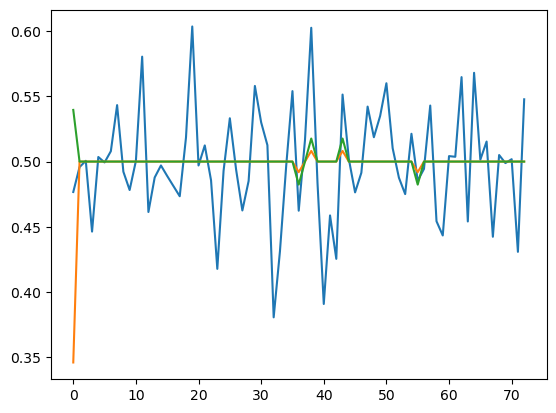

In [43]:
temp_df = pd.read_csv(f"{experiments_dir}/alpha=1.0_criterion=L2_lr=0.1_seed=1001.csv")
print(temp_df.shape)

plt.plot(temp_df.epoch, temp_df.train_auroc)
plt.plot(temp_df.epoch, temp_df.val_auroc)
plt.plot(temp_df.epoch, temp_df.test_auroc)

In [50]:
# AUROC

# CT
# Max: 0.629 +/- 0.049
# Mean: 0.707 +/- 0.088
# ABMIL: 0.648 +/- 0.100

# MRI
# Max: 0.759 +/- 0.024
# Mean: 0.809 +/- 0.029
# ABMIL: 0.807 +/- 0.023


In [ ]:
# AUPRC

# CT
# Max: 0.321 +/- 0.134
# Mean: 0.328 +/- 0.077
# ABMIL: 0.348 +/- 0.038

# MRI
# Max: 0.511 +/- 0.082
# Mean: 0.618 +/- 0.078
# ABMIL: 0.596 +/- 0.046


In [5]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ConvNeXt_Tiny'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/MedSAM'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/MedSAM_neck=False'
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=ConvNeXt-Tiny' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM_neck=False' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL', 'TransMIL', 'SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)
    

In [39]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L2']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_CT/ViT_B_16'
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_OASIS-3_MRI/ViT_B_16'
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_CT_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=ConvNeXt-Tiny' 
#experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM' 
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_embedding_level=True_encoder=MedSAM_neck=False' 
experiments_dir = '/cluster/tufts/hugheslab/dloevl01/pooling/experiments/RSNA/embedding_level=True'
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/OASIS-3_MRI_ViT_B_16' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Mean']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.0_criterion=L2_lr=0.0001_pooling=Mean_...,1001,0.763190,0.565160,0.630837,0.490382,0.490382,0.790000,0.542331,0.599630,0.451486,0.451486,0.768924,0.458676,0.576808,0.454542,0.454542
1,alpha=0.0_criterion=L2_lr=0.01_pooling=Mean_se...,2001,0.766375,0.561186,0.542925,1.028985,1.028985,0.897206,0.778007,0.744352,0.365013,0.365013,0.809820,0.581826,0.545451,1.020463,1.020463
2,alpha=0.0_criterion=L2_lr=0.001_pooling=Mean_s...,3001,0.762372,0.463235,0.661228,0.689359,0.689359,0.927064,0.826467,0.761532,0.338828,0.338828,0.780574,0.572956,0.650841,0.683385,0.683385


In [40]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.764 +/- 0.002
0.530 +/- 0.058


In [6]:
# AUROC

# CT
# Max: 0.620 +/- 0.084
# Mean: 0.701 +/- 0.087
# ABMIL: 0.625 +/- 0.121
# TransMIL: 0.648 +/- 0.097

# MRI ViT-B/16
# Max: 0.802 +/- 0.025
# Mean: 0.801 +/- 0.035
# ABMIL: 0.783 +/- 0.006
# TransMIL: 0.744 +/- 0.038

# MRI ConvNeXt-Tiny
# Max: 0.789 +/- 0.038
# Mean: 0.788 +/- 0.024
# ABMIL: 0.801 +/- 0.019
# TransMIL: 0.792 +/- 0.032
# SmAP: 0.803 +/- 0.031

# MRI MedSAM
# Max: 0.769 +/- 0.038
# Mean: 0.767 +/- 0.003
# ABMIL: 0.791 +/- 0.031
# TransMIL: 0.775 +/- 0.010
# SmAP: 0.788 +/- 0.025


In [ ]:
# AUPRC

# CT
# Max: 0.303 +/- 0.095
# Mean: 0.347 +/- 0.078
# ABMIL: 0.305 +/- 0.057
# TransMIL: 0.292 +/- 0.061

# MRI ViT-B/16
# Max: 0.562 +/- 0.081
# Mean: 0.613 +/- 0.079
# ABMIL: 0.555 +/- 0.028
# TransMIL: 0.498 +/- 0.085

# MRI ConvNeXt-Tiny
# Max: 0.562 +/- 0.086
# Mean: 0.531 +/- 0.037
# ABMIL: 0.531 +/- 0.037
# TransMIL: 0.571 +/- 0.115
# SmAP: 0.571 +/- 0.074

# MRI MedSAM
# Max: 0.509 +/- 0.102
# Mean: 0.510 +/- 0.013
# ABMIL: 0.547 +/- 0.007
# TransMIL: 0.522 +/- 0.027
# SmAP: 0.522 +/- 0.015
